# Lab 3 — Comprendre le taux d'apprentissage

## Objectifs

Dans ce notebook, nous allons :

- comprendre le rôle du taux d'apprentissage $\alpha$ ;
- observer comment il modifie la longueur d'un déplacement ;
- comparer une convergence lente, rapide et oscillatoire ;
- reconnaître une absence de convergence et une divergence ;
- établir mathématiquement la condition de convergence de notre exemple.

## 1. Pourquoi réutiliser la fonction du premier lab ?

Nous reprenons la fonction convexe :

$$f(x)=(x-3)^2+1$$

avec :

$$f'(x)=2(x-3).$$

Cette fonction possède un unique minimum global en $x=3$. Ainsi, si les trajectoires se comportent différemment, la cause sera uniquement le taux d'apprentissage et non la présence de plusieurs vallées.

## 2. Importer les bibliothèques

In [1]:
# NumPy permet de créer les grilles et de manipuler les trajectoires numériques.
import numpy as np

# Matplotlib permet de comparer visuellement les différents taux.
import matplotlib.pyplot as plt

# Ce style rend les graphiques plus lisibles.
plt.style.use("seaborn-v0_8-whitegrid")

## 3. Définir la fonction et son gradient

In [2]:
def fonction(x):
    """Calcule f(x) = (x - 3)² + 1."""
    # La fonction accepte un nombre ou un tableau NumPy.
    return (x - 3) ** 2 + 1


def gradient(x):
    """Calcule f'(x) = 2(x - 3)."""
    # Le résultat représente la pente locale de la fonction.
    return 2 * (x - 3)

## 4. Comparer une seule mise à jour

La règle est :

$$x_{nouveau}=x_{actuel}-\alpha f'(x_{actuel}).$$

Nous partons toujours de $x_0=0$. À ce point, le gradient vaut $-6$. Le taux $\alpha$ est donc la seule quantité qui modifie le déplacement.

In [3]:
# Point initial commun à toutes les expériences.
x_depart = 0.0

# Six taux choisis pour représenter six comportements différents.
taux_etudies = [0.02, 0.2, 0.5, 0.8, 1.0, 1.1]

# Calcul unique du gradient au point de départ.
pente_depart = gradient(x_depart)

# En-tête du tableau de résultats.
print(f"{'taux':>8} | {'gradient':>10} | {'déplacement':>12} | {'nouveau x':>10} | {'f(nouveau)':>11}")
print("-" * 65)

# Une mise à jour est calculée séparément pour chaque taux.
for taux in taux_etudies:
    # Le signe moins transforme la pente en direction de descente.
    deplacement = -taux * pente_depart

    # La nouvelle position est l'ancienne position plus le déplacement.
    x_nouveau = x_depart + deplacement

    # Affichage des quantités importantes.
    print(
        f"{taux:8.2f} | {pente_depart:10.2f} | {deplacement:12.2f} | "
        f"{x_nouveau:10.2f} | {fonction(x_nouveau):11.2f}"
    )

    taux |   gradient |  déplacement |  nouveau x |  f(nouveau)
-----------------------------------------------------------------
    0.02 |      -6.00 |         0.12 |       0.12 |        9.29
    0.20 |      -6.00 |         1.20 |       1.20 |        4.24
    0.50 |      -6.00 |         3.00 |       3.00 |        1.00
    0.80 |      -6.00 |         4.80 |       4.80 |        4.24
    1.00 |      -6.00 |         6.00 |       6.00 |       10.00
    1.10 |      -6.00 |         6.60 |       6.60 |       13.96


### Première interprétation

- $\alpha=0.02$ produit un petit déplacement ;
- $\alpha=0.2$ avance rapidement sans dépasser le minimum ;
- $\alpha=0.5$ arrive exactement en $x=3$ en une étape ;
- $\alpha=0.8$ dépasse le minimum et arrive de l'autre côté ;
- $\alpha=1$ arrive aussi loin du minimum que le point initial ;
- $\alpha=1.1$ arrive encore plus loin : la distance au minimum augmente.

## 5. Visualiser le premier pas

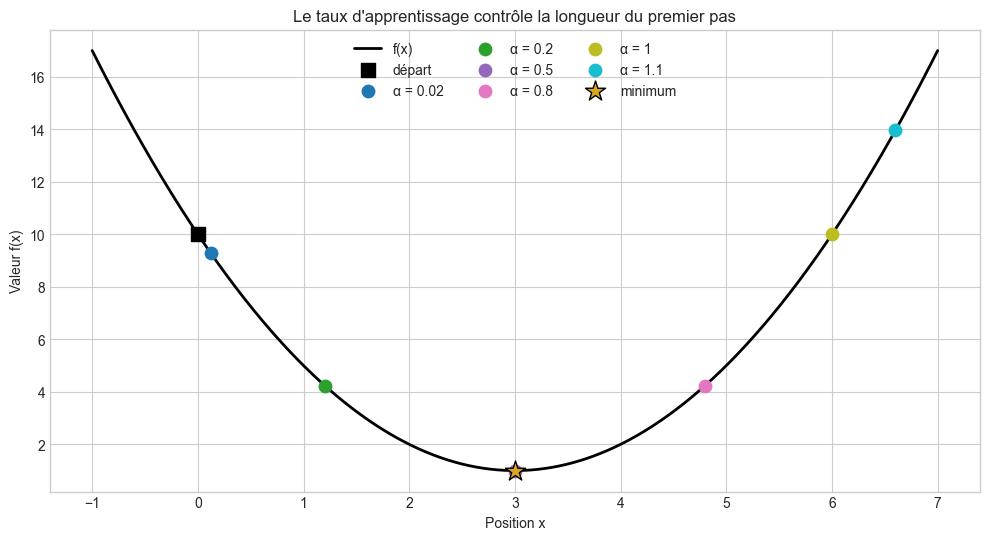

In [6]:
# Grille utilisée pour dessiner la fonction.
x_grille = np.linspace(-1, 7, 20000)
y_grille = fonction(x_grille)
# Une couleur différente est créée pour chaque taux.
couleurs = plt.cm.tab10(np.linspace(0, 1, len(taux_etudies)))

# Création de la figure.
fig, ax = plt.subplots(figsize=(12, 6))

# Tracé de la fonction complète.
ax.plot(x_grille, y_grille, color="black", linewidth=2, label="f(x)")

# Le point de départ est commun à toutes les expériences.
ax.scatter(x_depart, fonction(x_depart), marker="s", s=110, color="black", zorder=6, label="départ")

# Calcul et affichage de la destination du premier pas pour chaque taux.
for couleur, taux in zip(couleurs, taux_etudies):
    x_nouveau = x_depart - taux * gradient(x_depart)
    ax.scatter(
        x_nouveau,
        fonction(x_nouveau),
        s=80,
        color=couleur,
        zorder=5,
        label=f"α = {taux:g}",
    )

# Une étoile indique le minimum théorique.
ax.scatter(3, 1, marker="*", s=230, color="goldenrod", edgecolor="black", zorder=7, label="minimum")

ax.set_title("Le taux d'apprentissage contrôle la longueur du premier pas")
ax.set_xlabel("Position x")
ax.set_ylabel("Valeur f(x)")
ax.legend(ncol=3)
plt.show()

## 6. Répéter les mises à jour

In [7]:
def descente_gradient_1d(gradient_f, x_depart, taux, nombre_iterations):
    """Retourne toutes les positions visitées par la descente de gradient."""

    # La position actuelle commence au point initial.
    x = float(x_depart)

    # L'historique conserve le départ et toutes les positions suivantes.
    historique = [x]

    # Répétition de la mise à jour.
    for _ in range(nombre_iterations):
        # Calcul du gradient à la position courante.
        pente = gradient_f(x)

        # Le taux multiplie le gradient et contrôle la taille du pas.
        x = x - taux * pente

        # La nouvelle position est ajoutée à l'historique.
        historique.append(x)

    return np.array(historique)

In [11]:
# Quinze mises à jour suffisent pour distinguer les comportements.
nombre_iterations = 15

# Dictionnaire qui associe chaque taux à sa trajectoire.
trajectoires = {}

# Exécution de la descente pour chacun des six taux.
for taux in taux_etudies:
    trajectoires[taux] = descente_gradient_1d(
        gradient_f=gradient,
        x_depart=x_depart,
        taux=taux,
        nombre_iterations=nombre_iterations,
    )

# Affichage de la dernière position et de la distance au minimum.
print(f"{'taux':>8} | {'x final':>12} | {'distance à 3':>14} | {'f(x final)':>12}")
print("-" * 57)
for taux, trajet in trajectoires.items():
    x_final = trajet[-1]
    distance = abs(x_final - 3)
    print(f"{taux:8.2f} | {x_final:12.5f} | {distance:14.5f} | {fonction(x_final):12.5f}")

    taux |      x final |   distance à 3 |   f(x final)
---------------------------------------------------------
    0.02 |      1.37374 |        1.62626 |      3.64472
    0.20 |      2.99859 |        0.00141 |      1.00000
    0.50 |      3.00000 |        0.00000 |      1.00000
    0.80 |      3.00141 |        0.00141 |      1.00000
    1.00 |      6.00000 |        3.00000 |     10.00000
    1.10 |     49.22106 |       46.22106 |   2137.38682


## 7. Visualiser les positions selon l'itération

Les taux convergents sont séparés des taux non convergents afin que les grandes valeurs de la divergence ne masquent pas les autres courbes.

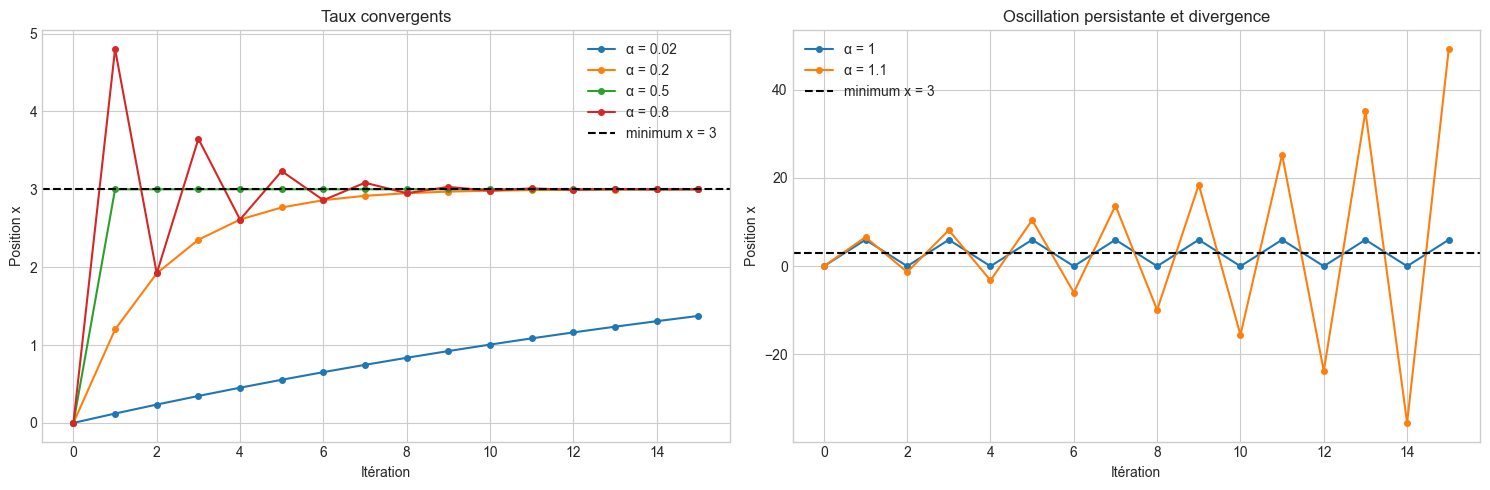

In [12]:
# Création de deux graphiques côte à côte.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Taux qui atteignent progressivement le minimum.
taux_convergents = [0.02, 0.2, 0.5, 0.8]

# Tracé des positions convergentes.
for taux in taux_convergents:
    trajet = trajectoires[taux]
    axes[0].plot(np.arange(len(trajet)), trajet, "o-", markersize=4, label=f"α = {taux:g}")

# Ligne horizontale représentant la position optimale.
axes[0].axhline(3, linestyle="--", color="black", label="minimum x = 3")
axes[0].set_title("Taux convergents")
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("Position x")
axes[0].legend()

# Taux situés sur la frontière ou au-delà de la stabilité.
taux_non_convergents = [1.0, 1.1]

# Tracé des oscillations et de la divergence.
for taux in taux_non_convergents:
    trajet = trajectoires[taux]
    axes[1].plot(np.arange(len(trajet)), trajet, "o-", markersize=4, label=f"α = {taux:g}")

axes[1].axhline(3, linestyle="--", color="black", label="minimum x = 3")
axes[1].set_title("Oscillation persistante et divergence")
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("Position x")
axes[1].legend()

plt.tight_layout()
plt.show()

### Lecture du graphique

Une courbe qui approche horizontalement $x=3$ converge. Une courbe qui traverse alternativement $x=3$ oscille. Si l'amplitude des oscillations diminue, elle converge ; si elle reste constante, elle ne converge pas ; si elle augmente, elle diverge.

## 8. Visualiser les déplacements sur la fonction

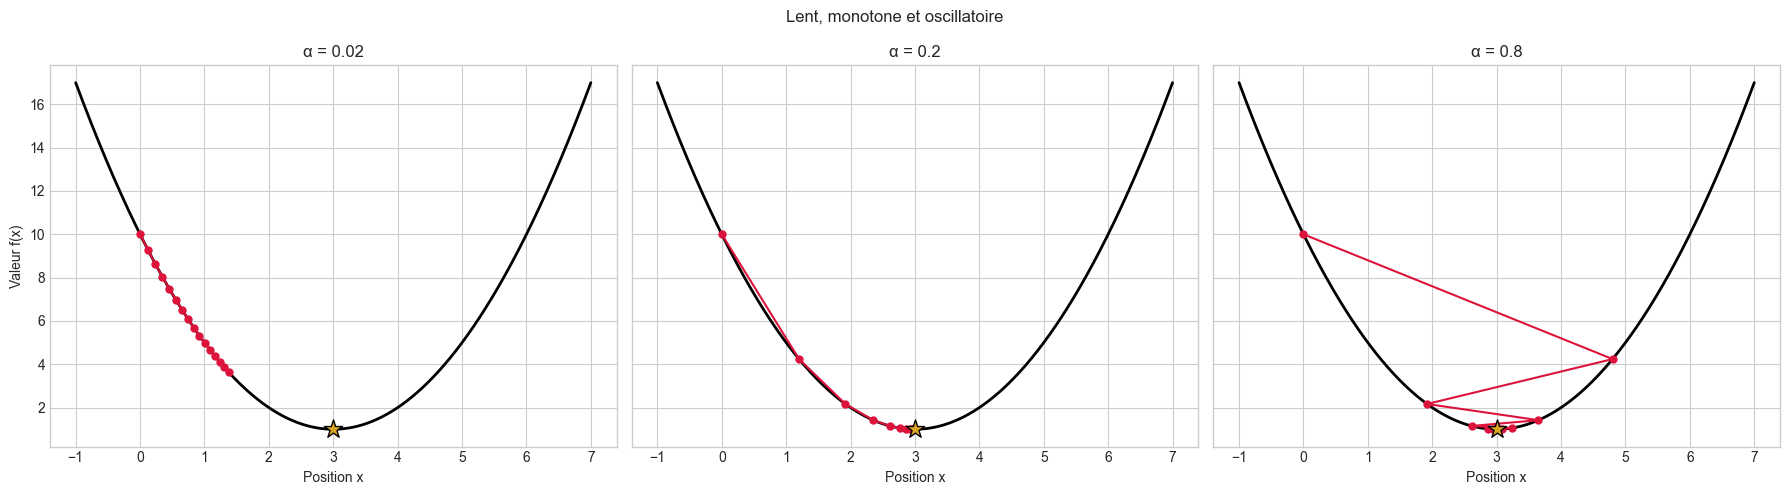

In [13]:
# Trois taux suffisent pour comparer les formes principales de convergence.
taux_a_visualiser = [0.02, 0.2, 0.8]

# Création d'un graphique par taux.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, taux in zip(axes, taux_a_visualiser):
    # Tracé de la fonction.
    ax.plot(x_grille, fonction(x_grille), color="black", linewidth=2)

    # Récupération de la trajectoire correspondant au taux.
    trajet = trajectoires[taux]

    # Tracé des positions successives directement sur la courbe.
    ax.plot(trajet, fonction(trajet), "o-", color="crimson", markersize=5)

    # Marquage du minimum global.
    ax.scatter(3, 1, marker="*", s=190, color="goldenrod", edgecolor="black", zorder=6)

    ax.set_title(f"α = {taux:g}")
    ax.set_xlabel("Position x")

axes[0].set_ylabel("Valeur f(x)")
fig.suptitle("Lent, monotone et oscillatoire")
plt.tight_layout()
plt.show()

## 9. Comparer l'erreur sur une échelle logarithmique

L'écart à la valeur minimale est $f(x_k)-1$. Une échelle logarithmique permet de voir simultanément les très petites et les très grandes erreurs.

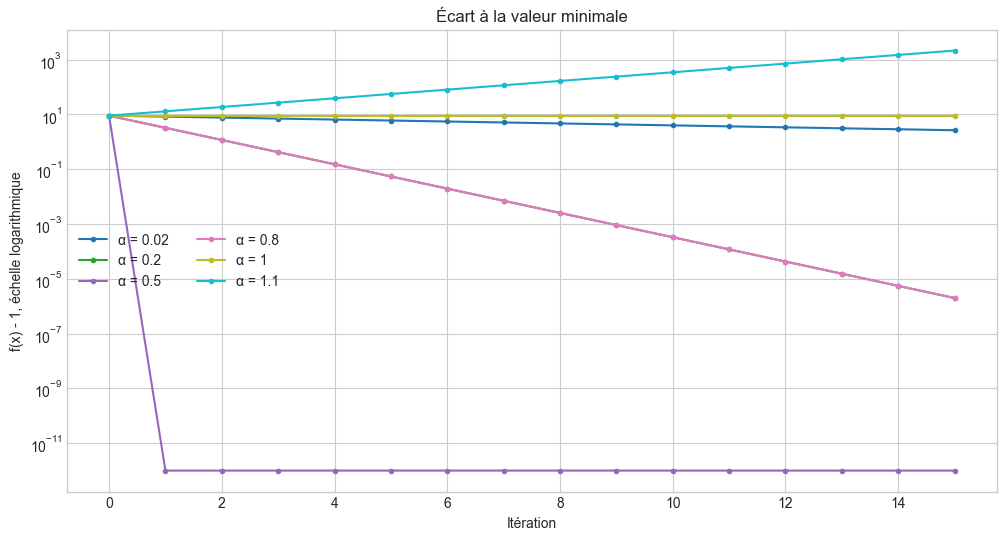

In [14]:
# Création de la figure de comparaison des erreurs.
fig, ax = plt.subplots(figsize=(12, 6))

for couleur, taux in zip(couleurs, taux_etudies):
    # Récupération de la trajectoire.
    trajet = trajectoires[taux]

    # Calcul de l'écart entre f(x) et la valeur minimale 1.
    ecart = fonction(trajet) - 1

    # Une très petite borne évite log(0) lorsque α = 0.5 atteint exactement le minimum.
    ecart_affichable = np.maximum(ecart, 1e-12)

    # Tracé de l'erreur au fil des itérations.
    ax.plot(np.arange(len(trajet)), ecart_affichable, "o-", markersize=3, color=couleur, label=f"α = {taux:g}")

# Passage de l'axe vertical à une échelle logarithmique.
ax.set_yscale("log")
ax.set_title("Écart à la valeur minimale")
ax.set_xlabel("Itération")
ax.set_ylabel("f(x) - 1, échelle logarithmique")
ax.legend(ncol=2)
plt.show()

### Observation importante

Les taux $0.2$ et $0.8$ donnent la même diminution de l'erreur dans cet exemple, car leurs facteurs sont respectivement $0.6$ et $-0.6$. Leur valeur absolue est identique. Le taux $0.8$ change cependant le signe de l'erreur à chaque étape : la position oscille autour du minimum, tandis que le taux $0.2$ l'approche toujours du même côté.

## 10. Condition mathématique de convergence

Pour notre fonction :

$$x_{k+1}=x_k-2\alpha(x_k-3).$$

Définissons l'erreur de position $e_k=x_k-3$. Nous obtenons :

$$e_{k+1}=(1-2\alpha)e_k.$$

Le nombre $1-2\alpha$ est le facteur appliqué à l'erreur après chaque étape. Pour que l'erreur tende vers zéro, sa valeur absolue doit être inférieure à $1$ :

$$|1-2\alpha|<1,$$

ce qui donne :

$$0<\alpha<1.$$

Cette limite dépend de la courbure de la fonction. La valeur $0.5$ n'est donc pas un taux universellement optimal : elle est spéciale pour cette fonction quadratique précise.

## 11. Résumé des régimes

| Valeur de $\alpha$ | Facteur $1-2\alpha$ | Comportement |
|---|---:|---|
| $0<\alpha<0.5$ | entre $0$ et $1$ | convergence sans dépassement |
| $\alpha=0.5$ | $0$ | minimum atteint en une étape |
| $0.5<\alpha<1$ | entre $-1$ et $0$ | convergence avec oscillations |
| $\alpha=1$ | $-1$ | oscillations constantes |
| $\alpha>1$ | inférieur à $-1$ | divergence oscillatoire |

## 12. Exercice

Pour chacun des taux `0.05`, `0.45`, `0.75`, `0.95`, `1.0` et `1.05` :

1. calcule mentalement le facteur `1 - 2 * taux` ;
2. prédis le comportement de la trajectoire ;
3. lance quinze itérations depuis `x_depart = 0` ;
4. trace la position selon l'itération ;
5. compare ta prédiction et le résultat.

### Bonus

Recommence depuis `x_depart = 6`. Vérifie que les régimes de convergence restent les mêmes, même si les premiers déplacements partent maintenant vers la gauche.